# Unemployment Analysis in India

### CodeAlpha Data Science Internship - Task 2

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Objective

To analyze unemployment trends in India, examine the impact of the COVID-19 period, identify regional and monthly patterns, and explore relationships between unemployment, employment and labour participation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Unemployment in India.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (768, 7)


In [2]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
print(df.columns.tolist())

['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [5]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [6]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [7]:
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nNew dataset shape:", df.shape)


Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

New dataset shape: (740, 7)


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df['Date'].head())
print("\nDate type:", df['Date'].dtype)

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]

Date type: datetime64[ns]


In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


In [11]:
print("Average Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Minimum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].min(), 2), "%")

print("Maximum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].max(), 2), "%")

Average Unemployment Rate: 11.79 %
Minimum Unemployment Rate: 0.0 %
Maximum Unemployment Rate: 76.74 %


In [12]:
print("Average Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Minimum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].min(), 2), "%")

print("Maximum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].max(), 2), "%")

Average Unemployment Rate: 11.79 %
Minimum Unemployment Rate: 0.0 %
Maximum Unemployment Rate: 76.74 %


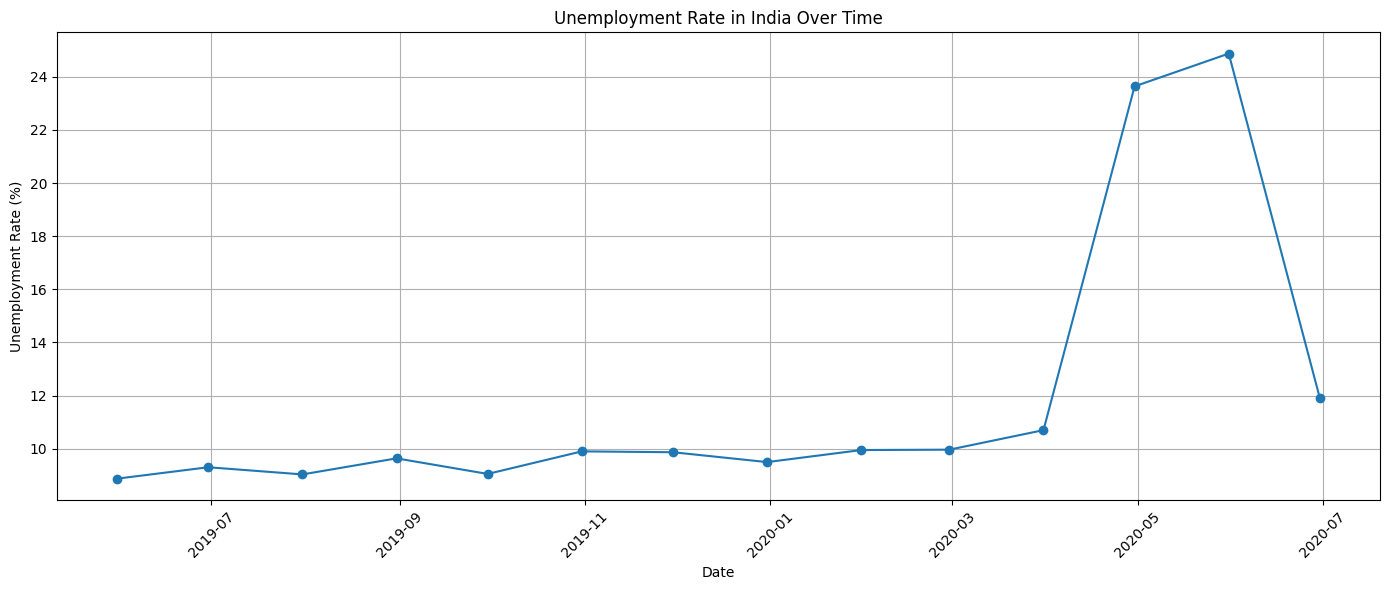

In [13]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title('Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
before_covid = df[df['Date'] < '2020-03-01']

during_covid = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-06-30')
]

print("Average unemployment before COVID:",
      round(before_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Average unemployment during COVID:",
      round(during_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")

Average unemployment before COVID: 9.51 %
Average unemployment during COVID: 17.77 %


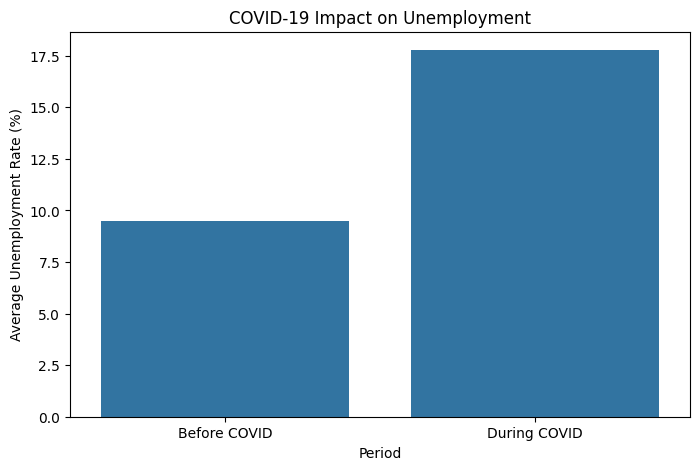

In [15]:
covid_comparison = pd.DataFrame({
    'Period': ['Before COVID', 'During COVID'],
    'Unemployment Rate': [
        before_covid['Estimated Unemployment Rate (%)'].mean(),
        during_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Unemployment Rate'
)

plt.title('COVID-19 Impact on Unemployment')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

In [16]:
print("Average Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Minimum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].min(), 2), "%")

print("Maximum Unemployment Rate:",
      round(df['Estimated Unemployment Rate (%)'].max(), 2), "%")

Average Unemployment Rate: 11.79 %
Minimum Unemployment Rate: 0.0 %
Maximum Unemployment Rate: 76.74 %


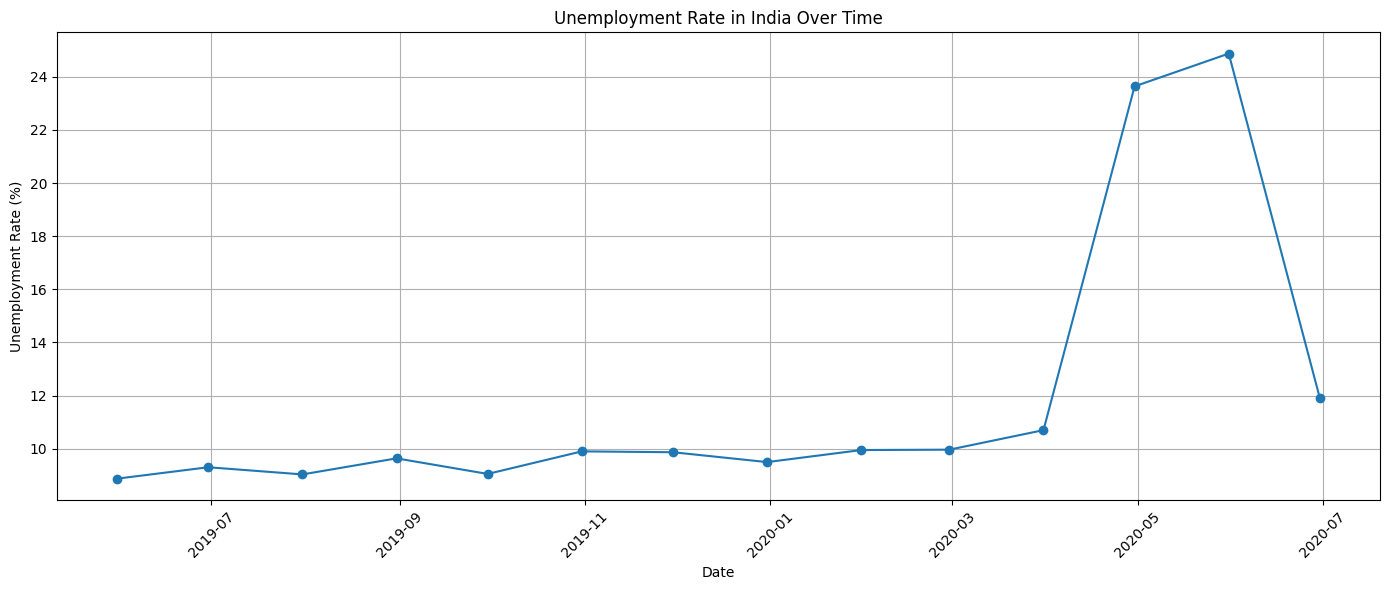

In [17]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title('Unemployment Rate in India Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
before_covid = df[df['Date'] < '2020-03-01']

during_covid = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-06-30')
]

print("Average unemployment before COVID:",
      round(before_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Average unemployment during COVID:",
      round(during_covid['Estimated Unemployment Rate (%)'].mean(), 2), "%")

Average unemployment before COVID: 9.51 %
Average unemployment during COVID: 17.77 %


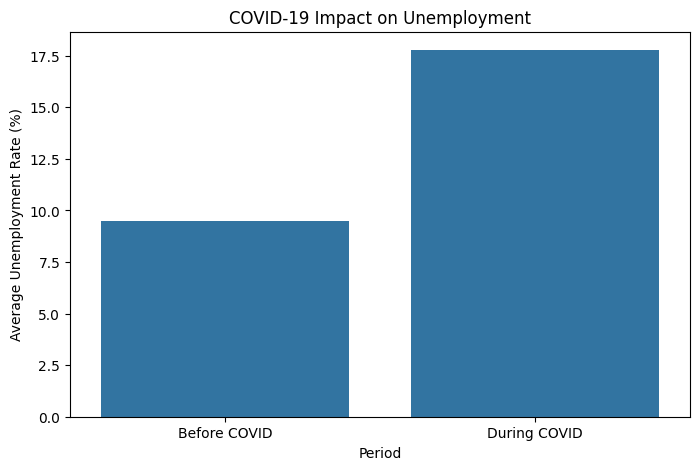

In [19]:
covid_comparison = pd.DataFrame({
    'Period': ['Before COVID', 'During COVID'],
    'Unemployment Rate': [
        before_covid['Estimated Unemployment Rate (%)'].mean(),
        during_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Unemployment Rate'
)

plt.title('COVID-19 Impact on Unemployment')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

In [20]:
region_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


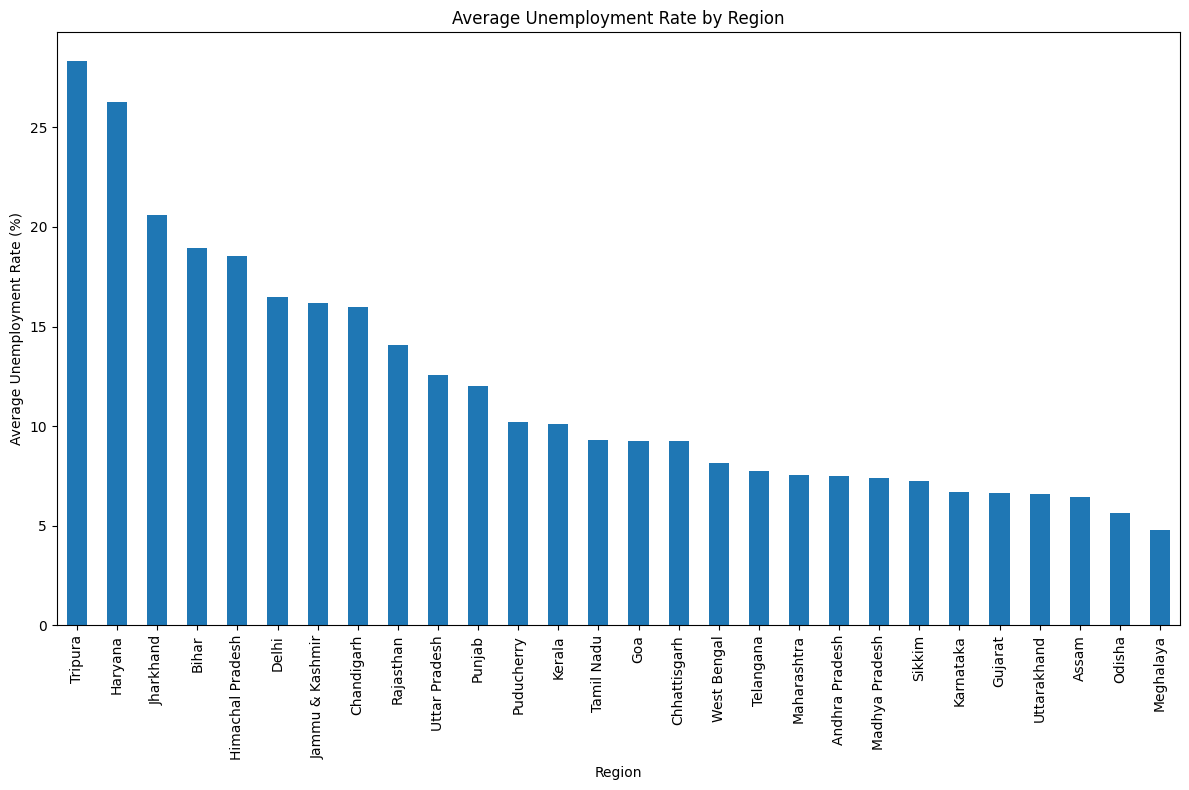

In [21]:
plt.figure(figsize=(12, 8))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [22]:
top_10_regions = region_unemployment.head(10)

print("Top 10 regions by average unemployment rate:")
print(top_10_regions)

Top 10 regions by average unemployment rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


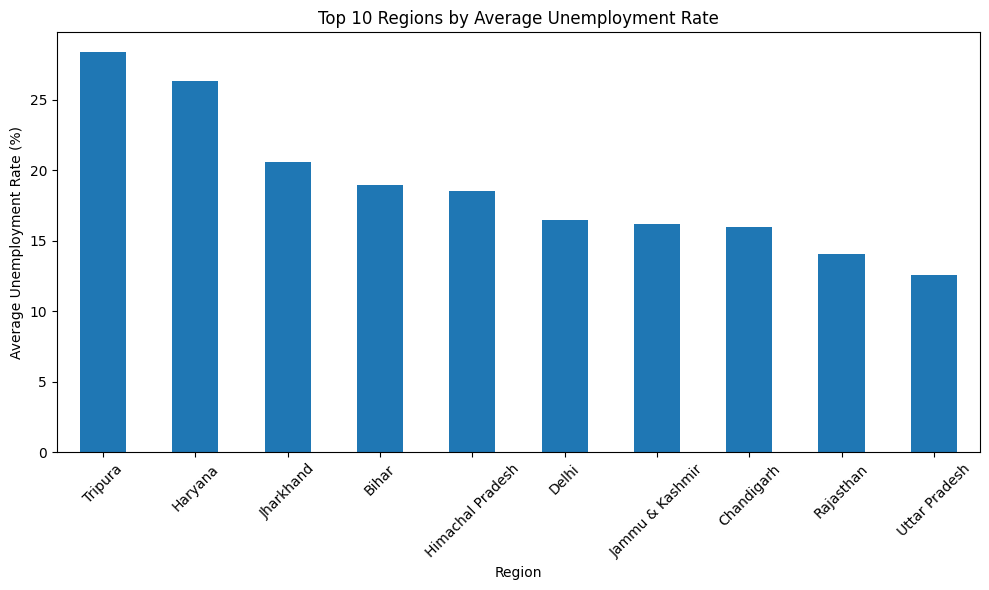

In [23]:
plt.figure(figsize=(10, 6))

top_10_regions.plot(kind='bar')

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
area_unemployment = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
)

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


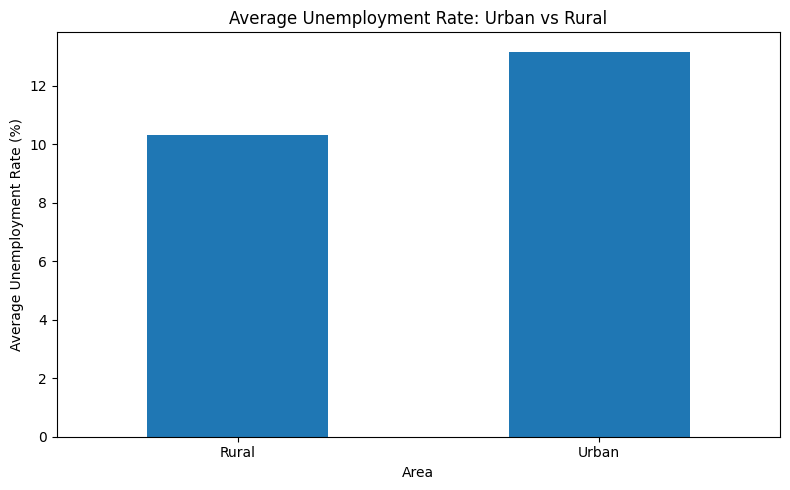

In [25]:
plt.figure(figsize=(8, 5))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate: Urban vs Rural')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
monthly_average = (
    df.groupby('Month_Name')['Estimated Unemployment Rate (%)']
    .mean()
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_average = monthly_average.reindex(month_order)

print(monthly_average)

Month_Name
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


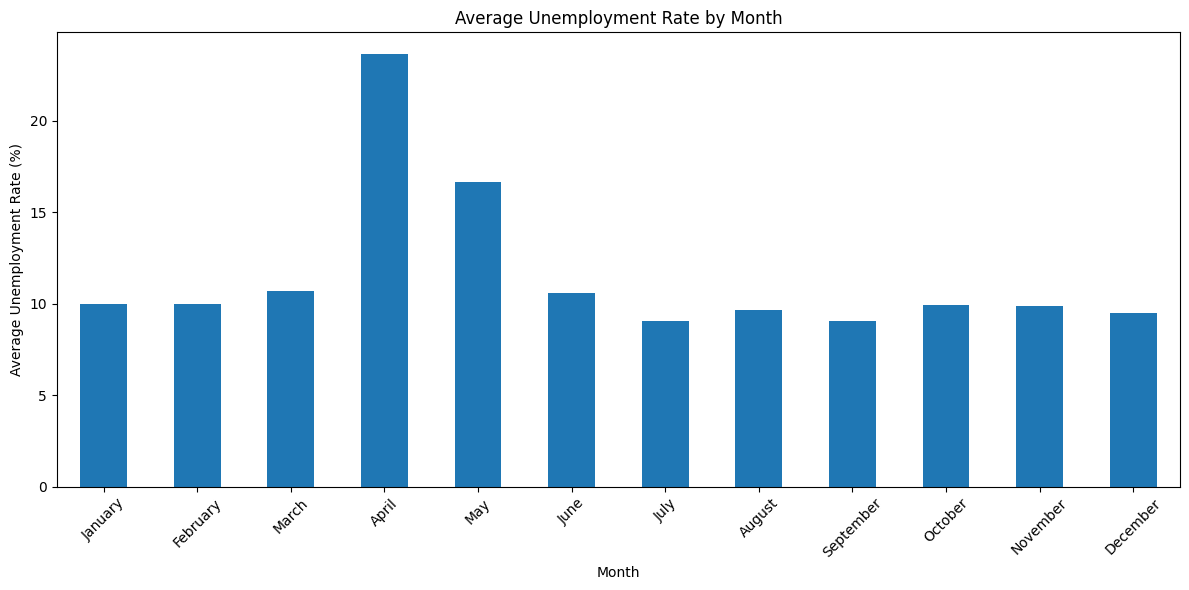

In [27]:
plt.figure(figsize=(12, 6))

monthly_average.plot(kind='bar')

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
labour_rate = 'Estimated Labour Participation Rate (%)'

yearly_labour = df.groupby('Year')[labour_rate].mean()

print("Average Labour Participation Rate by Year:")
print(yearly_labour)

Average Labour Participation Rate by Year:
Year
2019    43.88586
2020    40.88829
Name: Estimated Labour Participation Rate (%), dtype: float64


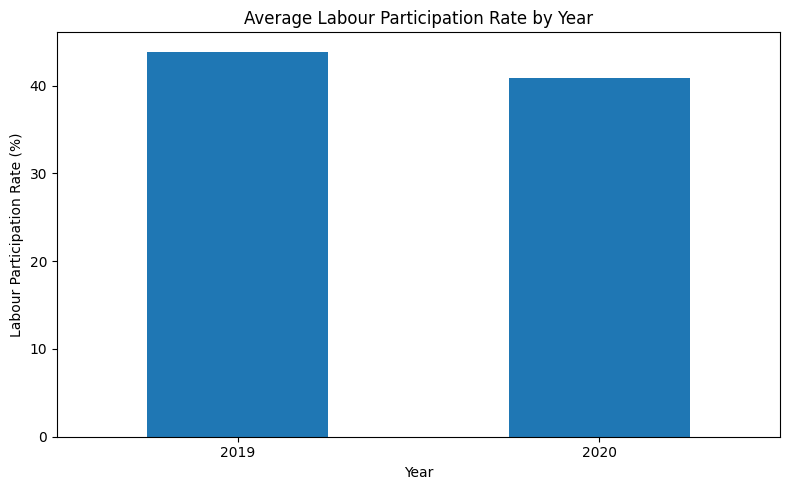

In [29]:
plt.figure(figsize=(8, 5))

yearly_labour.plot(kind='bar')

plt.title('Average Labour Participation Rate by Year')
plt.xlabel('Year')
plt.ylabel('Labour Participation Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
numeric_columns = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

correlation = df[numeric_columns].corr()

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


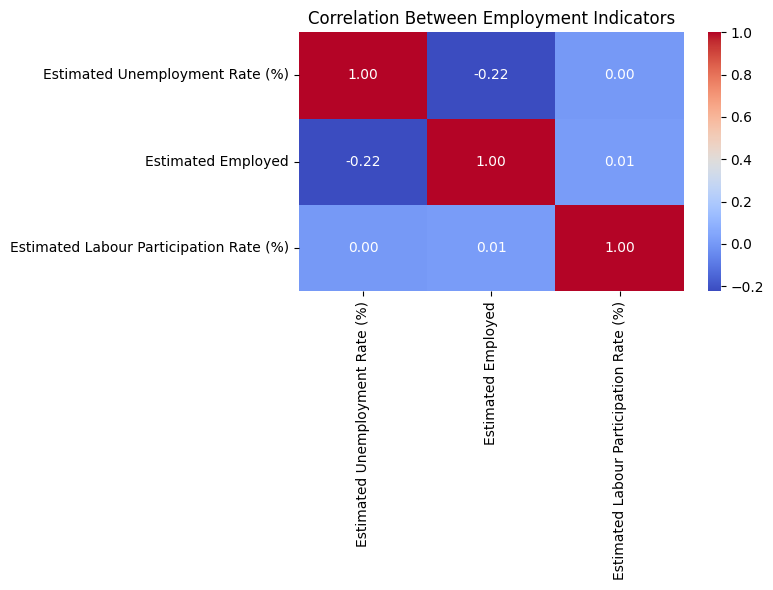

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between Employment Indicators')

plt.tight_layout()
plt.show()

In [32]:
yearly_unemployment = (
    df.groupby('Year')['Estimated Unemployment Rate (%)']
    .mean()
)

print(yearly_unemployment)

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


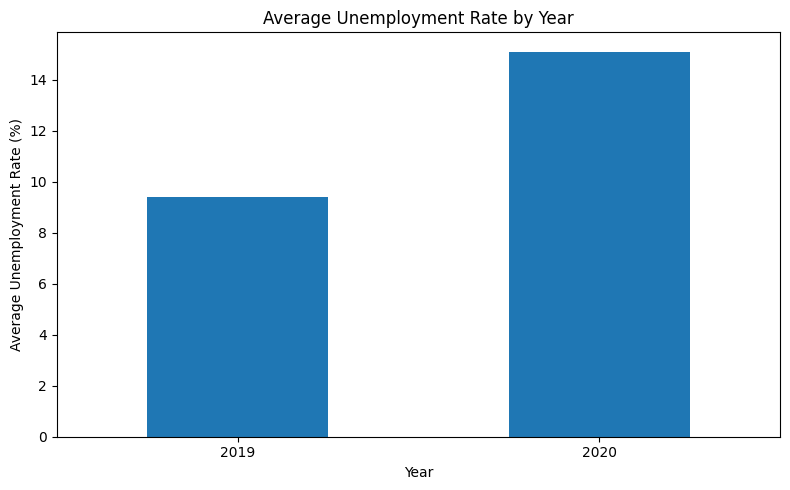

In [33]:
plt.figure(figsize=(8, 5))

yearly_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Year')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
summary = pd.DataFrame({
    'Average Unemployment Rate (%)': [
        df['Estimated Unemployment Rate (%)'].mean()
    ],
    'Minimum Unemployment Rate (%)': [
        df['Estimated Unemployment Rate (%)'].min()
    ],
    'Maximum Unemployment Rate (%)': [
        df['Estimated Unemployment Rate (%)'].max()
    ],
    'Average Labour Participation Rate (%)': [
        df['Estimated Labour Participation Rate (%)'].mean()
    ]
})

summary.round(2)

,Average Unemployment Rate (%),Minimum Unemployment Rate (%),Maximum Unemployment Rate (%),Average Labour Participation Rate (%)
0,11.79,0.0,76.74,42.63


# Key Findings

1. The overall average unemployment rate in the dataset was 11.79%.

2. The unemployment rate ranged from 0.00% to 76.74%, showing substantial variation across the observations.

3. The average unemployment rate increased from approximately 9.4% in 2019 to approximately 15.0% in 2020.

4. Before the selected COVID-19 period, the average unemployment rate was 9.51%. During the selected COVID-19 period from March to June 2020, it increased to 17.77%.

5. The comparison shows a substantial increase in unemployment during the selected COVID-19 period.

6. Unemployment rates varied across different regions of India, indicating geographical differences.

7. Urban and rural areas showed differences in their average unemployment rates.

8. Monthly analysis showed variations in unemployment rates across different months.

9. The average labour participation rate in the dataset was 42.63%.

10. Correlation analysis provides insight into the relationships between unemployment, employment and labour participation.

# Conclusion

This project analyzed unemployment in India using Python and the Unemployment in India dataset.

The analysis included data cleaning, descriptive statistics, time-series analysis, COVID-19 period analysis, regional comparison, urban-rural comparison, monthly analysis, labour participation analysis, and correlation analysis.

The overall average unemployment rate was 11.79%. The yearly analysis showed an increase in the average unemployment rate from approximately 9.4% in 2019 to approximately 15.0% in 2020.

The COVID-19 comparison showed that the average unemployment rate was 9.51% before the selected COVID-19 period and increased to 17.77% during the March-June 2020 period.

The analysis also showed differences in unemployment across regions, areas and months. Overall, the project demonstrates how Python, Pandas, Matplotlib and Seaborn can be used to clean, analyze and visualize economic data.